In [96]:
# Reiniciar las importaciones correctamente
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt  # Forma alternativa y más explícita de importar
import seaborn as sns

# Verificar la importación
print(type(plt.figure))

<class 'function'>


In [97]:
clientes = pd.read_excel('../clean_data/clientes.xlsx')
detalle_ventas = pd.read_excel('../clean_data/detalles_ventas_clean.xlsx')
productos = pd.read_excel('../clean_data/productos_clean.xlsx')
ventas = pd.read_excel('../clean_data/ventas_clean.xlsx')

df_list = [clientes, detalle_ventas, productos, ventas]

### ESTADISTICAS DESCRIPTIVAS

In [98]:
name_list = ["clientes", "detalle_ventas", "productos", "ventas"]

for i, tabla in enumerate(df_list):
    print(f"\nEstadísticas descriptivas para {name_list[i]}:")
    print("\nInformación general:")
    print(tabla.info())

    print("\nEstadísticas numéricas:")
    print(tabla.describe())
    
    print("\nValores nulos por columna:")
    print(tabla.isnull().sum())

    # Mostrar primeras filas
    print("\nPrimeras filas del dataset:")
    print(tabla.head())

    print("\n" + "="*50)


Estadísticas descriptivas para clientes:

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_cliente      100 non-null    int64         
 1   nombre_cliente  100 non-null    object        
 2   email           100 non-null    object        
 3   ciudad          100 non-null    object        
 4   fecha_alta      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.0+ KB
None

Estadísticas numéricas:
       id_cliente           fecha_alta
count  100.000000                  100
mean    50.500000  2023-02-19 12:00:00
min      1.000000  2023-01-01 00:00:00
25%     25.750000  2023-01-25 18:00:00
50%     50.500000  2023-02-19 12:00:00
75%     75.250000  2023-03-16 06:00:00
max    100.000000  2023-04-10 00:00:00
std     29.011492                  NaN

Valores nulos por 

### ANALISIS DE CORRELACIONES 


=========== CORRELACIONES PARA CLIENTES ===========
            id_cliente
id_cliente         1.0


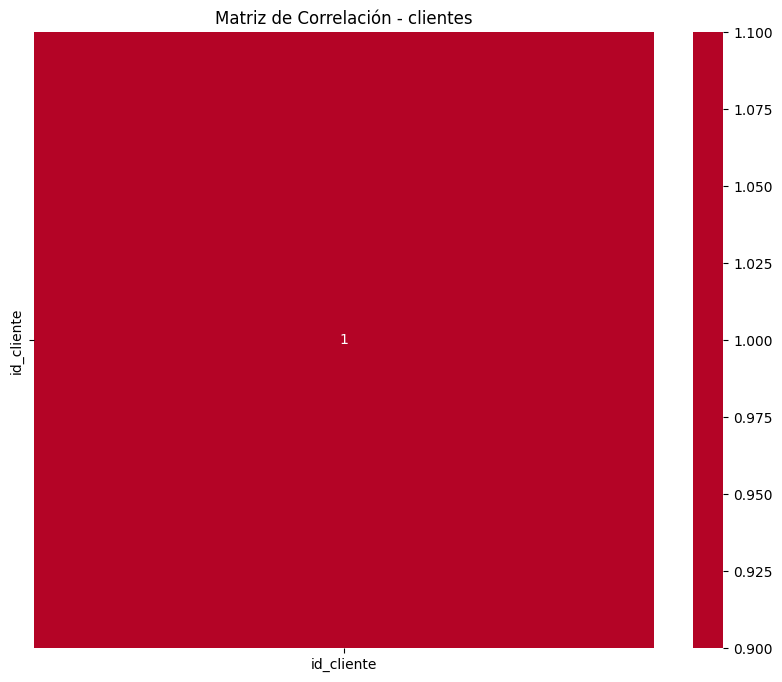


Correlaciones más significativas:
No se encontraron correlaciones significativas (>0.5)


=========== CORRELACIONES PARA DETALLE_VENTAS ===========
                 id_venta  id_producto  cantidad  precio_unitario   importe
id_venta         1.000000    -0.042161  0.037559        -0.094872 -0.063107
id_producto     -0.042161     1.000000  0.076373         0.002185  0.048966
cantidad         0.037559     0.076373  1.000000        -0.074483  0.599723
precio_unitario -0.094872     0.002185 -0.074483         1.000000  0.679298
importe         -0.063107     0.048966  0.599723         0.679298  1.000000


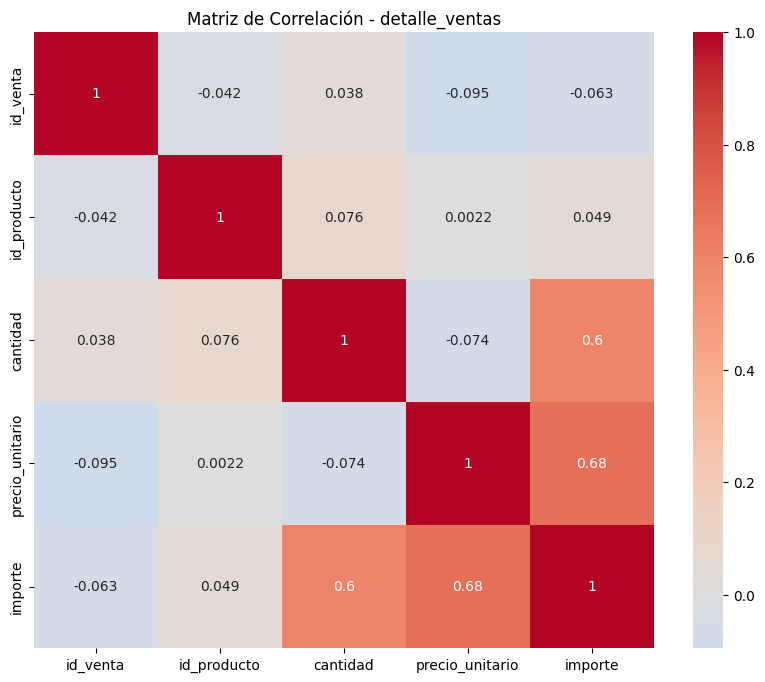


Correlaciones más significativas:
precio_unitario  importe            0.679298
importe          precio_unitario    0.679298
cantidad         importe            0.599723
importe          cantidad           0.599723
dtype: float64


=========== CORRELACIONES PARA PRODUCTOS ===========
                 id_producto  precio_unitario
id_producto          1.00000         -0.03798
precio_unitario     -0.03798          1.00000


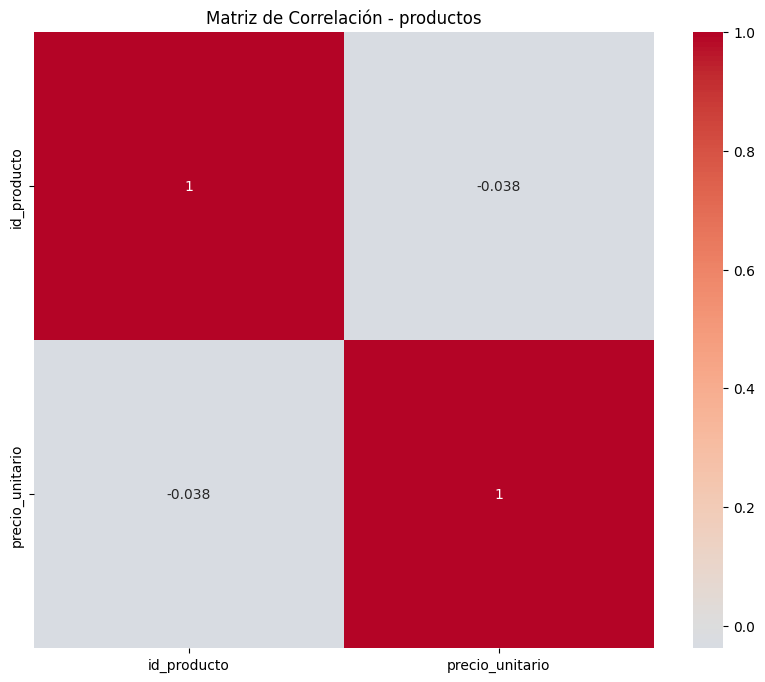


Correlaciones más significativas:
No se encontraron correlaciones significativas (>0.5)


=========== CORRELACIONES PARA VENTAS ===========
            id_venta  id_cliente
id_venta    1.000000    0.008391
id_cliente  0.008391    1.000000


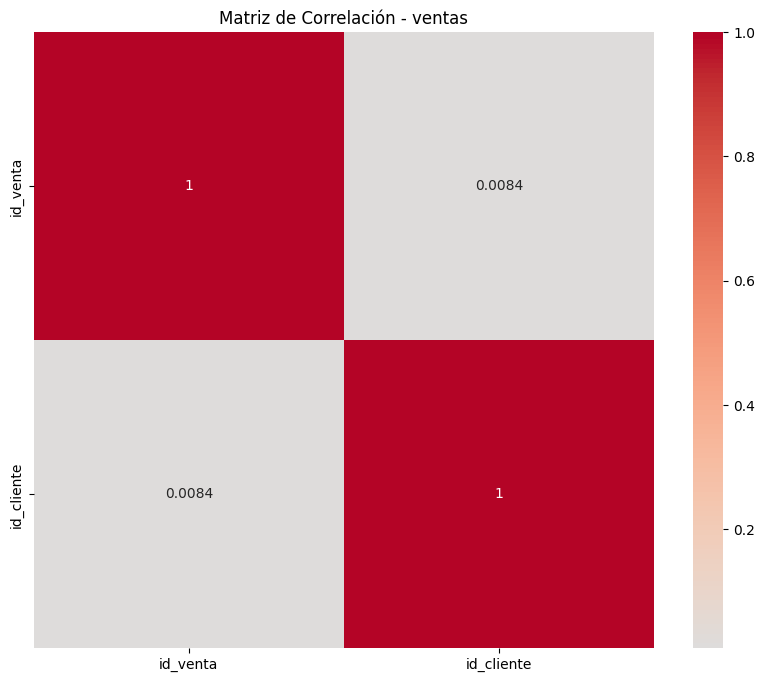


Correlaciones más significativas:
No se encontraron correlaciones significativas (>0.5)



In [99]:
name_list = ["clientes", "detalle_ventas", "productos", "ventas"]

for i, tabla in enumerate(df_list):
    print(f"\n=========== CORRELACIONES PARA {name_list[i].upper()} ===========")
    
    numericas = tabla.select_dtypes(include=[np.number])
    
    if not numericas.empty:
        corr = numericas.corr()
        print(corr)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
        ax.set_title(f'Matriz de Correlación - {name_list[i]}')
        plt.show()
        
        print("\nCorrelaciones más significativas:")
        corr_unstack = corr.unstack()
        corr_sorted = corr_unstack[abs(corr_unstack) > 0.5]
        corr_sorted = corr_sorted[corr_sorted != 1.0] #elimino autocorrelaciones
        if not corr_sorted.empty:
            print(corr_sorted.sort_values(ascending=False))
        else:
            print("No se encontraron correlaciones significativas (>0.5)")
    else:
        print(f"No hay variables numéricas en {name_list[i]} para calcular correlaciones")
    
    print("\n" + "="*50)

## Observaciones 
- Hacer un merge de todas las tablas 
- Eliminar columnas duplicadas 
- Convertir los tipos de datos (preprocesamiento de datos)
- Crear nuevas columnas (mes, anio, dia de la semana)
- Graficar usando mpl
- Graficar usando sns

In [ ]:
df_productos = productos
# setear previamente todo como alimento
KEYWORDS_LIMPIEZA = ['DETERGENTE', 'LAVANDINA', 'CLORO', 'JABÓN', 'ESPONJA', 'ESCOBA', 'DESINFECTANTE', 'SUAVIZANTE']

def clasificar_producto(nombre_producto):
    """Clasifica el producto basado en palabras clave en su nombre."""
    # Convertimos a mayúsculas para asegurar la búsqueda sin sensibilidad a mayúsculas
    nombre = str(nombre_producto).upper()
    
    # Comprobamos si alguna palabra clave de limpieza está en el nombre
    for keyword in KEYWORDS_LIMPIEZA:
        if keyword in nombre:
            return 'LIMPIEZA'
            
    # Si no se encuentra ninguna palabra de limpieza, se asume la otra macro-categoría
    return 'ALIMENTOS'

# --- Aplicación de la reestructuración ---

# Cargar el DataFrame (asumiendo que df_productos ya fue cargado)
# df_productos = pd.read_csv("productos_clean.xlsx - Sheet1.csv") 

# Crear la nueva columna 'categoria_correcta' aplicando la función a la columna 'nombre_producto'
df_productos['categoria_correcta'] = df_productos['nombre_producto'].apply(clasificar_producto)

# Reemplazar la columna antigua por la nueva (reestructurando el dataset)
df_productos['categoria'] = df_productos['categoria_correcta']
df_productos.drop(columns=['categoria_correcta'], inplace=True)

# 3. Mostrar el dataset final reestructurado
print("--- Dataset Final Reestructurado (Primeros 10 Registros) ---")
print(df_productos[['nombre_producto', 'categoria']].sample(50))

--- Dataset Final Reestructurado (Primeros 10 Registros) ---
                nombre_producto  categoria
0                COCA COLA 1.5L  ALIMENTOS
1                    PEPSI 1.5L  ALIMENTOS
2                   SPRITE 1.5L  ALIMENTOS
3            FANTA NARANJA 1.5L  ALIMENTOS
4            AGUA MINERAL 500ML  ALIMENTOS
5            JUGO DE NARANJA 1L  ALIMENTOS
6            JUGO DE MANZANA 1L  ALIMENTOS
7        ENERGÉTICA NITRO 500ML  ALIMENTOS
8          YERBA MATE SUAVE 1KG  ALIMENTOS
9        YERBA MATE INTENSA 1KG  ALIMENTOS
10             CAFÉ MOLIDO 250G  ALIMENTOS
11         TÉ NEGRO 20 SAQUITOS  ALIMENTOS
12         TÉ VERDE 20 SAQUITOS  ALIMENTOS
13              LECHE ENTERA 1L  ALIMENTOS
14          LECHE DESCREMADA 1L  ALIMENTOS
15           YOGUR NATURAL 200G  ALIMENTOS
16           QUESO CREMOSO 500G  ALIMENTOS
17           QUESO RALLADO 150G  ALIMENTOS
18                 MANTECA 200G  ALIMENTOS
19            PAN LACTAL BLANCO  ALIMENTOS
20          PAN LACTAL INTEGRAL  ALI

## Revisión de columnas en cada tabla

In [101]:
# Veamos las columnas de cada DataFrame
print("Columnas en productos:")
print(productos.columns.tolist())
print("\nColumnas en detalle_ventas:")
print(detalle_ventas.columns.tolist())

Columnas en productos:
['id_producto', 'nombre_producto', 'categoria', 'precio_unitario']

Columnas en detalle_ventas:
['id_venta', 'id_producto', 'nombre_producto', 'cantidad', 'precio_unitario', 'importe']


In [ ]:
#iniciar desde detalle_venta
df_venta_cliente = ventas.merge(clientes[['ciudad', 'id_cliente']], on='id_cliente' , how='left')
df_todos = detalle_ventas.merge(df_venta_cliente[["fecha","medio_pago","id_venta"]], on='id_venta', how='left').merge(df_productos, on='id_producto', how='left')
# traer todos los campos, no suponer ni omitir
display(df_todos.describe())
display(df_todos.columns)
display(df_todos.head())



,id_venta,id_producto,cantidad,precio_unitario_x,importe,fecha,precio_unitario_y
count,343.000000,343.000000,343.000000,343.000000,343.000000,343,343.000000
mean,61.492711,49.139942,2.962099,2654.495627,7730.078717,2024-03-30 14:12:14.693877504,2654.495627
min,1.000000,1.000000,1.000000,272.000000,272.000000,2024-01-02 00:00:00,272.000000
25%,31.000000,23.000000,2.000000,1618.500000,3489.000000,2024-02-10 12:00:00,1618.500000
50%,61.000000,47.000000,3.000000,2512.000000,6702.000000,2024-03-26 00:00:00,2512.000000
75%,93.000000,76.000000,4.000000,3876.000000,10231.500000,2024-05-21 00:00:00,3876.000000
max,120.000000,100.000000,5.000000,4982.000000,24865.000000,2024-06-28 00:00:00,4982.000000
std,34.835525,29.135461,1.366375,1308.694720,5265.543077,NaN,1308.694720


Index(['id_venta', 'id_producto', 'nombre_producto_x', 'cantidad',
       'precio_unitario_x', 'importe', 'fecha', 'medio_pago',
       'nombre_producto_y', 'categoria', 'precio_unitario_y'],
      dtype='object')

,id_venta,id_producto,nombre_producto_x,cantidad,precio_unitario_x,importe,fecha,medio_pago,nombre_producto_y,categoria,precio_unitario_y
0,1,90,TOALLAS HÚMEDAS X50,1,2902,2902,2024-06-19,TARJETA,TOALLAS HÚMEDAS X50,ALIMENTOS,2902
1,2,82,ACEITUNAS NEGRAS 200G,5,2394,11970,2024-03-17,QR,ACEITUNAS NEGRAS 200G,ALIMENTOS,2394
2,2,39,HELADO VAINILLA 1L,5,469,2345,2024-03-17,QR,HELADO VAINILLA 1L,ALIMENTOS,469
3,2,70,FERNET 750ML,2,4061,8122,2024-03-17,QR,FERNET 750ML,ALIMENTOS,4061
4,2,22,MEDIALUNAS DE MANTECA,1,2069,2069,2024-03-17,QR,MEDIALUNAS DE MANTECA,ALIMENTOS,2069


Todos id's, emails, nombre cliente, 

In [103]:
df = df_todos

df = df.drop(columns=['id_venta','id_producto','nombre_producto_x','precio_unitario_x'])
df.rename(columns={'nombre_producto_y':'producto','precio_unitario_y':'precio','importe':'total'}, inplace=True)

df = df[['producto','categoria','cantidad','precio','total','medio_pago','fecha']]
display(df.tail())

,producto,categoria,cantidad,precio,total,medio_pago,fecha
338,FERNET 750ML,ALIMENTOS,2,4061,8122,EFECTIVO,2024-02-09
339,CEPILLO DE DIENTES,ALIMENTOS,3,2142,6426,EFECTIVO,2024-02-09
340,AZÚCAR 1KG,ALIMENTOS,2,727,1454,EFECTIVO,2024-02-09
341,FIDEOS SPAGHETTI 500G,ALIMENTOS,5,745,3725,QR,2024-02-07
342,PAN LACTAL BLANCO,ALIMENTOS,5,1571,7855,TARJETA,2024-04-21


In [ ]:
#Transformar datos
medios = {"EFECTIVO": 0 , "TARJETA": 1, "QR":2, "TRANSFERENCIA": 3}
# anotar como observacion que es cada codigo de metodo de pago
df["medio_pago"] = df["medio_pago"].replace(medios)

display(df.tail())
display(df.sample(20))



C:\Users\César\AppData\Local\Temp\ipykernel_14588\818493212.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["medio_pago"] = df["medio_pago"].replace(medios)


,producto,categoria,cantidad,precio,total,medio_pago,fecha
338,FERNET 750ML,ALIMENTOS,2,4061,8122,0,2024-02-09
339,CEPILLO DE DIENTES,ALIMENTOS,3,2142,6426,0,2024-02-09
340,AZÚCAR 1KG,ALIMENTOS,2,727,1454,0,2024-02-09
341,FIDEOS SPAGHETTI 500G,ALIMENTOS,5,745,3725,2,2024-02-07
342,PAN LACTAL BLANCO,ALIMENTOS,5,1571,7855,1,2024-04-21


,producto,categoria,cantidad,precio,total,medio_pago,fecha
78,ALFAJOR SIMPLE,ALIMENTOS,2,2502,5004,2,2024-02-20
85,TOALLAS HÚMEDAS X50,ALIMENTOS,3,2902,8706,1,2024-05-22
195,HAMBURGUESAS CONGELADAS X4,ALIMENTOS,4,2420,9680,2,2024-06-02
334,VINO TINTO MALBEC 750ML,ALIMENTOS,4,4719,18876,1,2024-03-14
32,MERMELADA DE FRUTILLA 400G,ALIMENTOS,4,1584,6336,0,2024-06-28
96,CHOCOLATE AMARGO 100G,ALIMENTOS,5,2234,11170,3,2024-01-13
112,SAL FINA 500G,ALIMENTOS,1,1745,1745,1,2024-03-08
319,CREMA DENTAL 90G,ALIMENTOS,3,2512,7536,3,2024-03-08
84,CREMA DENTAL 90G,ALIMENTOS,4,2512,10048,1,2024-05-22
249,ENERGÉTICA NITRO 500ML,ALIMENTOS,4,4218,16872,0,2024-06-21


In [ ]:
# Procesamiento de fechas
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df['fecha'].dt.month
df['anio'] = df['fecha'].dt.year
df['dia_semana'] = df['fecha'].dt.day_name()

# Mostrar el resultado
print("\nPrimeras filas con las nuevas columnas temporales:")
display(df.head())

# Verificar valores únicos
print("\nValores únicos por columna temporal:")
print("Meses:", df['mes'].unique())
print("Años:", df['anio'].unique())
print("Días de la semana:", df['dia_semana'].unique())

## Análisis Visual de los Datos - OUTLIERS

A continuación, realizaremos diferentes visualizaciones para entender mejor los patrones en nuestros datos:

In [ ]:
def analizar_valores_extremos(df, columna):
    """Analiza los valores extremos de una columna específica."""
    print(f"\n{'='*20} Valores extremos para {columna.upper()} {'='*20}")
    
    # estadistico
    media = df[columna].mean()
    std = df[columna].std()
    
    print(f"\nEstadísticas básicas:")
    print(f"Media: {media:.2f}")
    print(f"Desviación estándar: {std:.2f}")
    
    print("\nValores mínimos:")
    display(df.nsmallest(5, columna)[['producto', columna]])
    
    print("\nValores máximos:")
    display(df.nlargest(5, columna)[['producto', columna]])
    
    # outliers
    lower_bound = media - 2 * std
    upper_bound = media + 2 * std
    outliers = df[(df[columna] < lower_bound) | (df[columna] > upper_bound)]
    
    if not outliers.empty:
        print(f"\nOutliers detectados: {len(outliers)} registros")
        display(outliers[['producto', columna]])

#valores extremos para las variables que son  numéricas
for columna in ['cantidad', 'precio', 'total']:
    analizar_valores_extremos(df, columna)


==================== Valores extremos para CANTIDAD ====================

Estadísticas básicas:
Media: 2.96
Desviación estándar: 1.37

Valores mínimos:


,producto,cantidad
0,TOALLAS HÚMEDAS X50,1
4,MEDIALUNAS DE MANTECA,1
8,JUGO EN POLVO NARANJA,1
14,QUESO UNTABLE 190G,1
24,STEVIA 100 SOBRES,1



Valores máximos:


,producto,cantidad
1,ACEITUNAS NEGRAS 200G,5
2,HELADO VAINILLA 1L,5
10,BIZCOCHOS SALADOS,5
17,LAVANDINA 1L,5
19,VINO BLANCO 750ML,5



==================== Valores extremos para PRECIO ====================

Estadísticas básicas:
Media: 2654.50
Desviación estándar: 1308.69

Valores mínimos:


...

,producto,total
128,PAN LACTAL INTEGRAL,272
286,TURRÓN 50G,503
169,PAN LACTAL INTEGRAL,544
263,TÉ NEGRO 20 SAQUITOS,570
214,ACEITE DE GIRASOL 1L,860



Valores máximos:


,producto,total
208,PEPSI 1.5L,24865
141,CARAMELOS MASTICABLES,23760
41,BARRITA DE CEREAL 30G,22150
54,PIZZA CONGELADA MUZZARELLA,21430
175,ENERGÉTICA NITRO 500ML,21090



Outliers detectados: 22 registros


,producto,total
22,TRAPO DE PISO,19416
37,RON 700ML,19380
41,BARRITA DE CEREAL 30G,22150
54,PIZZA CONGELADA MUZZARELLA,21430
87,RON 700ML,19380
103,STEVIA 100 SOBRES,19240
109,CARAMELOS MASTICABLES,19008
141,CARAMELOS MASTICABLES,23760
143,DESODORANTE AEROSOL,18760
158,YERBA MATE SUAVE 1KG,19390


### GRAFICOS VARIOS 
verificar validez

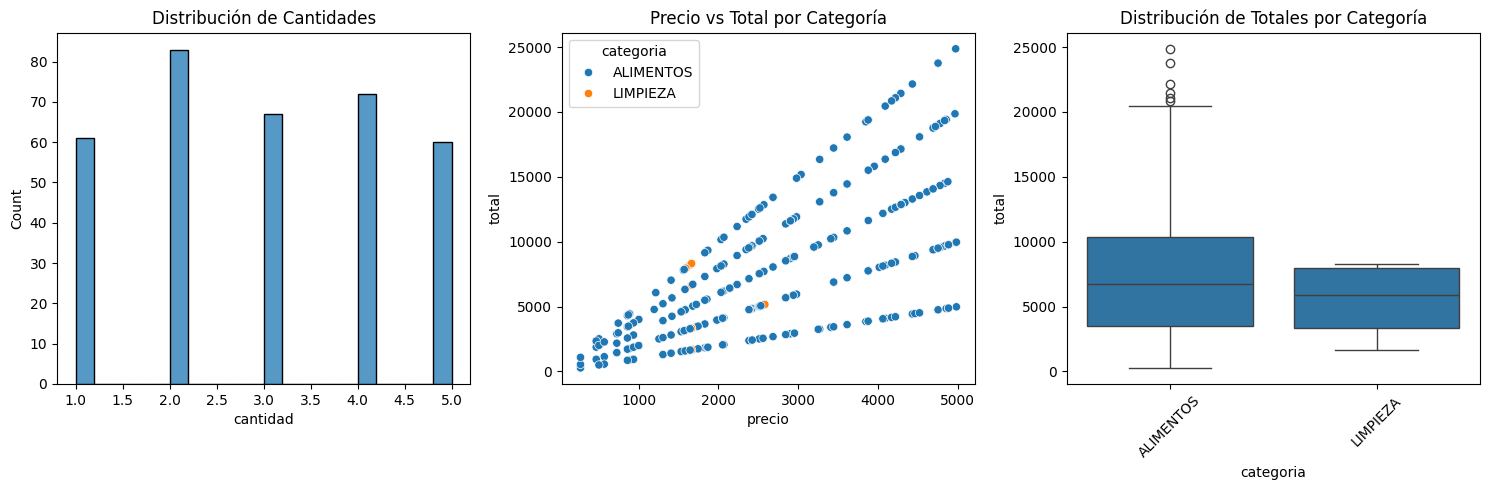

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# 1. Distribución de cantidades
sns.histplot(data=df, x='cantidad', bins=20, ax=ax1)
ax1.set_title('Distribución de Cantidades')

# 2. Relación Precio vs Total
sns.scatterplot(data=df, x='precio', y='total', hue='categoria', ax=ax2)
ax2.set_title('Precio vs Total por Categoría')

# 3. Distribución de totales por categoría
sns.boxplot(data=df, x='categoria', y='total', ax=ax3)
ax3.set_title('Distribución de Totales por Categoría')
ax3.tick_params(axis='x', rotation=45)

# Ajustar el layout
plt.tight_layout()
plt.show()

## Interpretación de Resultados

Del análisis realizado podemos concluir:

1. **Distribución de Cantidades**
   - La mayoría de las ventas son de pocas unidades
   - Hay algunos casos de ventas con cantidades grandes
   - La distribución está sesgada hacia la derecha

2. **Relación Precio-Total**
   - Existe una correlación positiva entre precio y total
   - Las categorías muestran patrones diferentes
   - Algunos productos tienen precios significativamente más altos

3. **Análisis por Categoría**
   - Hay diferencias notables en los totales entre categorías
   - Cada categoría tiene sus propios rangos de precios
   - Se identifican algunos valores atípicos importantes

4. **Valores Extremos**
   - Se detectaron outliers en cantidades y precios
   - Los valores extremos pueden indicar:
     * Ventas especiales o promociones
     * Posibles errores en los datos
     * Patrones de compra únicos